<a href="https://colab.research.google.com/github/bintangrz2704/Proyek_DatMin/blob/main/Proyek_Artikel_Datmin_Revisi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Membaca Dataset**

In [ ]:
#Import Library untuk Membaca dan Mengolah Data


import pandas as pd
import numpy as np

In [ ]:
# Pastikan file Nilai_OR(1).csv sudah diupload ke Google Colab
df = pd.read_csv("/content/Nilai_OR.csv")

# Menampilkan 5 data pertama
df.head()

,id,jenis kelamin,senam ritmik,renang,atletik
0,10811,L,85,88,92
1,10849,L,85,87,88
2,10595,P,85,85,88
3,10597,P,85,86,92
4,10598,L,80,96,84


**Pemeriksaan Data Awal**

In [ ]:
#Melihat Jumlah Baris dan Kolom Dataset


print("Jumlah baris dan kolom:", df.shape)

Jumlah baris dan kolom: (138, 5)


In [ ]:
#Melihat Nama-Nama Variabel dalam Dataset


print("Daftar nama kolom:")
print(df.columns)

Daftar nama kolom:
Index(['id', 'jenis kelamin', 'senam ritmik', 'renang', 'atletik'], dtype='object')


In [ ]:
#Melihat Informasi Umum Dataset


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             138 non-null    int64 
 1   jenis kelamin  138 non-null    object
 2   senam ritmik   138 non-null    int64 
 3   renang         138 non-null    int64 
 4   atletik        138 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 5.5+ KB


In [ ]:
#Mengecek Missing Value


print("Jumlah missing value pada setiap kolom:")
print(df.isnull().sum())

Jumlah missing value pada setiap kolom:
id               0
jenis kelamin    0
senam ritmik     0
renang           0
atletik          0
dtype: int64


In [ ]:
#Mengecek Data Duplikat


print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [ ]:
#Merapikan Nama Kolom


# Nama kolom dibuat huruf kecil, spasi diganti underscore,
# dan tanda yang tidak perlu dihapus agar mudah dipanggil dalam kode.

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Nama kolom setelah dirapikan:")
print(df.columns)

Nama kolom setelah dirapikan:
Index(['id', 'jenis_kelamin', 'senam_ritmik', 'renang', 'atletik'], dtype='object')


**Preprocessing Data**

In [ ]:
#Menentukan Variabel yang Digunakan untuk Clustering


# Variabel ID tidak digunakan dalam proses clustering.
# Variabel jenis_kelamin hanya digunakan untuk analisis tambahan.
# Variabel utama untuk K-Means adalah nilai senam_ritmik, renang, dan atletik.

feature_cols = ["senam_ritmik", "renang", "atletik"]

X = df[feature_cols]

X.head()

,senam_ritmik,renang,atletik
0,85,88,92
1,85,87,88
2,85,85,88
3,85,86,92
4,80,96,84


In [ ]:
#Memastikan Data Nilai Berbentuk Numerik


# Data nilai harus berbentuk angka agar bisa diproses oleh K-Means.

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

X = df[feature_cols]

print(X.dtypes)

senam_ritmik    int64
renang          int64
atletik         int64
dtype: object


**Statistik Deskriptif Nilai Olahraga**

In [ ]:
#Melihat Statistik Deskriptif Nilai Olahraga


X.describe()

,senam_ritmik,renang,atletik
count,138.000000,138.000000,138.000000
mean,85.246377,85.086957,77.594203
std,2.556833,4.611123,10.402581
min,75.000000,75.000000,50.000000
25%,85.000000,84.000000,70.000000
50%,85.000000,86.000000,78.000000
75%,87.000000,87.000000,86.000000
max,90.000000,97.000000,94.000000


**Normalisasi Data**

In [ ]:

#Import Library untuk Normalisasi Data


from sklearn.preprocessing import StandardScaler

In [ ]:
#Melakukan Normalisasi Data


# K-Means bekerja berdasarkan jarak.
# Karena itu, data perlu dinormalisasi agar setiap variabel memiliki skala yang seimbang.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Mengubah hasil normalisasi menjadi DataFrame agar mudah dibaca
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

X_scaled_df.head()

,senam_ritmik,renang,atletik
0,-0.096711,0.634044,1.389874
1,-0.096711,0.416387,1.003953
2,-0.096711,-0.018927,1.003953
3,-0.096711,0.198730,1.389874
4,-2.059379,2.375300,0.618033


**Penentuan Jumlah Cluster**

In [ ]:
#Import Library untuk K-Means dan Visualisasi


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

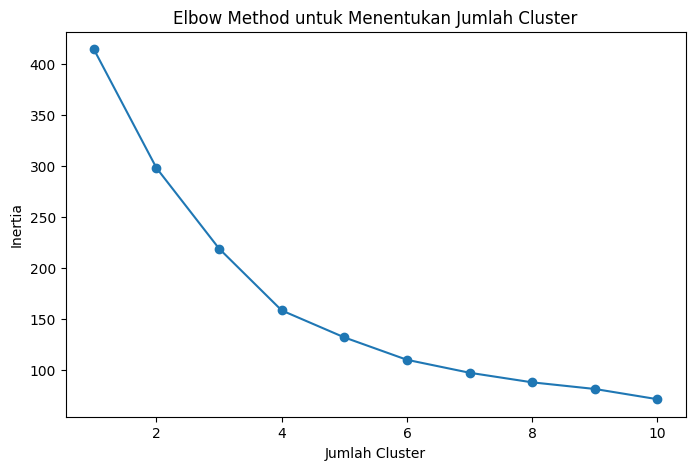

In [ ]:
#Menentukan Jumlah Cluster dengan Elbow Method


inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method untuk Menentukan Jumlah Cluster")
plt.show()

In [ ]:
#Menghitung Silhouette Score


silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    "jumlah_cluster": list(K_range),
    "silhouette_score": silhouette_scores
})

silhouette_df

,jumlah_cluster,silhouette_score
0,2,0.318370
1,3,0.351198
2,4,0.358937
3,5,0.381433
4,6,0.386716
5,7,0.351481
6,8,0.333348
7,9,0.335917
8,10,0.317626


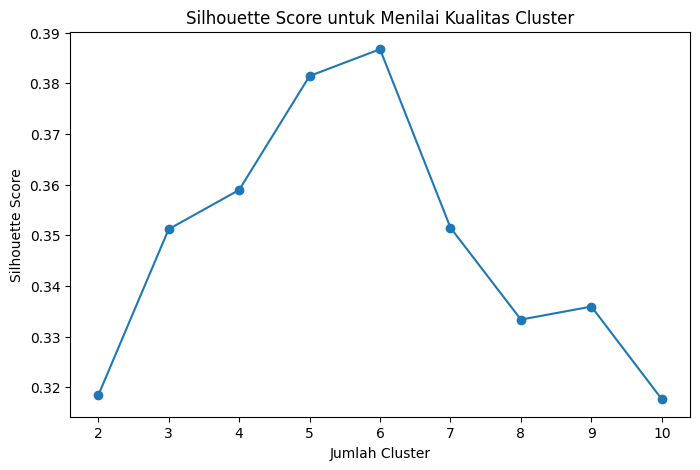

In [ ]:
#Menampilkan Grafik Silhouette Score


plt.figure(figsize=(8, 5))
plt.plot(silhouette_df["jumlah_cluster"], silhouette_df["silhouette_score"], marker="o")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score untuk Menilai Kualitas Cluster")
plt.show()

In [ ]:
#Menentukan Jumlah Cluster yang Digunakan


# Dalam penelitian ini, jumlah cluster ditetapkan menjadi 3.
# Cluster 3 dipilih agar hasil dapat diinterpretasikan sebagai:
# potensi tinggi, potensi sedang, dan potensi rendah.

k_terpilih = 3

**Hasil Clustering K-Means**

In [ ]:
#Menerapkan Algoritma K-Means


kmeans_final = KMeans(
    n_clusters=k_terpilih,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans_final.fit_predict(X_scaled)

df.head()

,id,jenis_kelamin,senam_ritmik,renang,atletik,cluster
0,10811,L,85,88,92,0
1,10849,L,85,87,88,0
2,10595,P,85,85,88,0
3,10597,P,85,86,92,0
4,10598,L,80,96,84,1


In [ ]:
#Melihat Jumlah Siswa pada Setiap Cluster


jumlah_cluster = df["cluster"].value_counts().sort_index()

print("Jumlah siswa pada setiap cluster:")
print(jumlah_cluster)

Jumlah siswa pada setiap cluster:
cluster
0    78
1    43
2    17
Name: count, dtype: int64


**Karakteristik Setiap Cluster**

In [ ]:
#Menghitung Rata-Rata Nilai Tiap Cluster


cluster_profile = df.groupby("cluster")[feature_cols].mean()

cluster_profile

,senam_ritmik,renang,atletik
cluster,,,
0,86.269231,86.256410,83.974359
1,83.674419,86.953488,67.860465
2,84.529412,75.000000,72.941176


In [ ]:
#Menghitung Rata-Rata Total Nilai Tiap Cluster


cluster_profile["rata_rata_total"] = cluster_profile.mean(axis=1)

cluster_profile

,senam_ritmik,renang,atletik,rata_rata_total
cluster,,,,
0,86.269231,86.256410,83.974359,85.500000
1,83.674419,86.953488,67.860465,79.496124
2,84.529412,75.000000,72.941176,77.490196


**Hasil Kategori Potensi Atlet Sekolah**

In [ ]:

#Memberi Interpretasi Potensi pada Setiap Cluster


# Cluster dengan rata-rata total tertinggi diberi label Potensi Tinggi.
# Cluster dengan rata-rata total sedang diberi label Potensi Sedang.
# Cluster dengan rata-rata total terendah diberi label Potensi Rendah.

urutan_cluster = cluster_profile["rata_rata_total"].sort_values(ascending=False).index

label_potensi = {
    urutan_cluster[0]: "Potensi Tinggi",
    urutan_cluster[1]: "Potensi Sedang",
    urutan_cluster[2]: "Potensi Rendah"
}

df["kategori_potensi"] = df["cluster"].map(label_potensi)

df.head()

,id,jenis_kelamin,senam_ritmik,renang,atletik,cluster,kategori_potensi
0,10811,L,85,88,92,0,Potensi Tinggi
1,10849,L,85,87,88,0,Potensi Tinggi
2,10595,P,85,85,88,0,Potensi Tinggi
3,10597,P,85,86,92,0,Potensi Tinggi
4,10598,L,80,96,84,1,Potensi Sedang


In [ ]:
#Melihat Hasil Akhir Cluster dan Kategori Potensi


df[["id", "jenis_kelamin", "senam_ritmik", "renang", "atletik", "cluster", "kategori_potensi"]].head()

,id,jenis_kelamin,senam_ritmik,renang,atletik,cluster,kategori_potensi
0,10811,L,85,88,92,0,Potensi Tinggi
1,10849,L,85,87,88,0,Potensi Tinggi
2,10595,P,85,85,88,0,Potensi Tinggi
3,10597,P,85,86,92,0,Potensi Tinggi
4,10598,L,80,96,84,1,Potensi Sedang


In [ ]:

#Menampilkan Jumlah Siswa Berdasarkan Kategori Potensi


print("Jumlah siswa berdasarkan kategori potensi:")
print(df["kategori_potensi"].value_counts())

Jumlah siswa berdasarkan kategori potensi:
kategori_potensi
Potensi Tinggi    78
Potensi Sedang    43
Potensi Rendah    17
Name: count, dtype: int64


**Analisis Jenis Kelamin Setiap Cluster**

In [ ]:
#Analisis Jenis Kelamin pada Setiap Cluster


gender_cluster = pd.crosstab(
    df["cluster"],
    df["jenis_kelamin"]
)

gender_cluster

jenis_kelamin,L,P
cluster,,
0,17,61
1,29,14
2,10,7


In [ ]:
#Analisis Jenis Kelamin Berdasarkan Kategori Potensi


gender_potensi = pd.crosstab(
    df["kategori_potensi"],
    df["jenis_kelamin"]
)

gender_potensi

jenis_kelamin,L,P
kategori_potensi,,
Potensi Rendah,10,7
Potensi Sedang,29,14
Potensi Tinggi,17,61


**Visualisasi Hasil Clustering**

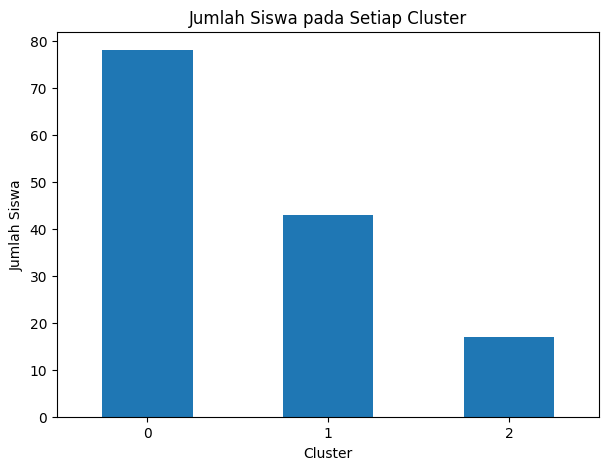

In [ ]:
#Visualisasi Jumlah Siswa pada Setiap Cluster


jumlah_cluster.plot(kind="bar", figsize=(7, 5))

plt.xlabel("Cluster")
plt.ylabel("Jumlah Siswa")
plt.title("Jumlah Siswa pada Setiap Cluster")
plt.xticks(rotation=0)
plt.show()

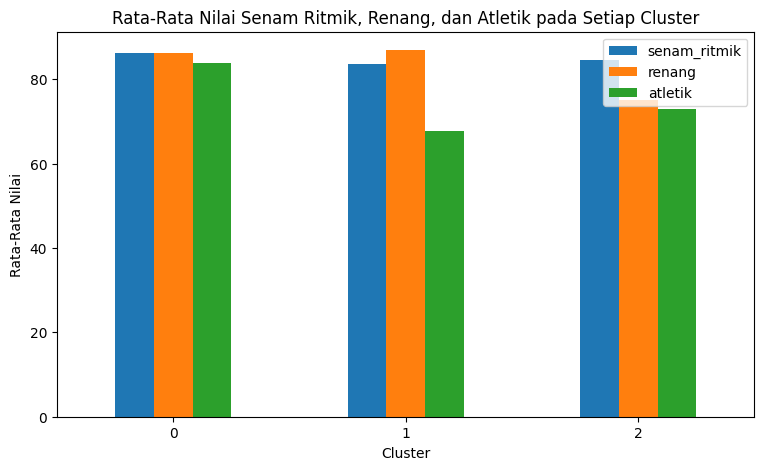

In [ ]:
#Visualisasi Rata-Rata Nilai Tiap Cluster


cluster_profile[feature_cols].plot(kind="bar", figsize=(9, 5))

plt.xlabel("Cluster")
plt.ylabel("Rata-Rata Nilai")
plt.title("Rata-Rata Nilai Senam Ritmik, Renang, dan Atletik pada Setiap Cluster")
plt.xticks(rotation=0)
plt.show()

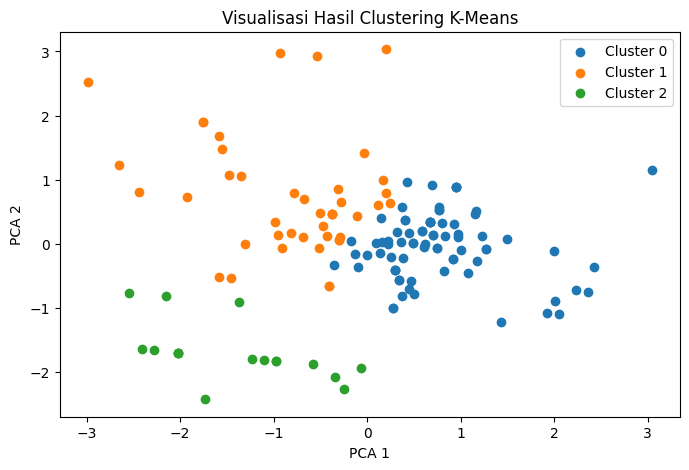

In [ ]:
#Visualisasi Cluster Menggunakan PCA


from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

plt.figure(figsize=(8, 5))

for cluster in sorted(df["cluster"].unique()):
    data_cluster = df[df["cluster"] == cluster]
    plt.scatter(
        data_cluster["pca1"],
        data_cluster["pca2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Visualisasi Hasil Clustering K-Means")
plt.legend()
plt.show()

In [ ]:
#Menyimpan Hasil Clustering ke File CSV


df.to_csv("hasil_clustering_potensi_atlet.csv", index=False)

print("File hasil_clustering_potensi_atlet.csv berhasil disimpan.")

File hasil_clustering_potensi_atlet.csv berhasil disimpan.


In [ ]:
#Mengunduh File CSV dari Google Colab


from google.colab import files

files.download("hasil_clustering_potensi_atlet.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>